# 01 Comparing IDR and DNAseI peaks

first, sort the consensus peaks bed files

` sort -k 1,1 -k2,2n consensus_regions.bed > consensus_regions.sort.bed`

In [1]:
import pandas as pd
import numpy as np
import pyranges as pr
import os
import glob

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

# DNAse I

Loaded ENCFF199VFY: 112,776 peaks
                   chrom  chromStart   chromEnd name  score strand  \
0                   chrM           0      16569    .   1000      .   
1                   chr3    93470361   93470800    .   1000      .   
2       chrUn_KI270438v1      101291     112502    .   1000      .   
3                   chr3    48496708   48604250    .   1000      .   
4                   chr9   136272578  136384511    .   1000      .   
...                  ...         ...        ...  ...    ...    ...   
105236              chr5    81854354   81855478    .    543      .   
105237              chr7    43161214   43161970    .    540      .   
105238              chr9     4674593    4675380    .    540      .   
105239              chr9    72955249   72956048    .    542      .   
105240              chrX    77046084   77046857    .    542      .   

        signalValue  pvalue  qvalue  summit  localIDR  globalIDR  \
0        5948.20920      -1      -1     869  5.000000   5

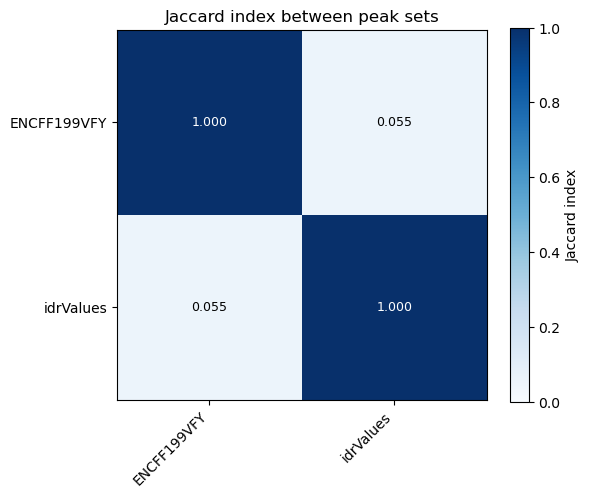

In [ ]:
import pandas as pd
import pyranges as pr
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# ================================================================== #
# 0. Load files
# ================================================================== #

pr_dict = {}

# --- filter FDR < 0.05 ---
fdr_files = glob.glob("/atac/COLO/FIRE/ENCFF199VFY.bed.gz") # DNASee I file from ENCODE

for filepath in fdr_files:
    sample_name = os.path.basename(filepath).replace(".bed.gz", "")
    df = pd.read_csv(filepath, sep="\t", #comment="#",
                     header=None, 
                     names=["Chromosome", "Start", "End", "name", "score",
                             "strand", "value", "anothervalue", "qvalue", "summit"])  


    pr_dict[sample_name] = pr.PyRanges(df.drop_duplicates().reset_index(drop=True))
    print(f"Loaded {sample_name}: {len(df):,} peaks")

# --- IDR.txt — filter by IDR score ---
idr_files = glob.glob("/atac/COLO/idr/idrValues.txt")

for filepath in idr_files:
    sample_name = os.path.basename(filepath).replace(".txt", "")
    df = pd.read_csv(filepath, sep="\t", header=None,
                     names=["chrom", "chromStart", "chromEnd", "name", "score",
                             "strand", "signalValue", "pvalue", "qvalue", "summit",
                             "localIDR", "globalIDR", "rep1_chromStart", "rep1_chromEnd",
                             "rep1_signalValue", "rep1_summit","x","x1","x2","x3"])
    print(df)

    df = df[["chrom", "chromStart", "chromEnd"]].rename(columns={
        "chrom"      : "Chromosome",
        "chromStart" : "Start",
        "chromEnd"   : "End"
    })
    
    df["Start"] = pd.to_numeric(df["Start"], errors="coerce")
    df["End"]   = pd.to_numeric(df["End"],   errors="coerce")
    df = df.dropna(subset=["Start", "End"])
    df["Start"] = df["Start"].astype(int)
    df["End"]   = df["End"].astype(int)

    pr_dict[sample_name] = pr.PyRanges(df.drop_duplicates().reset_index(drop=True))
    print(f"Loaded {sample_name}: {len(df):,}")

# ================================================================== #
# 1. Jaccard index per pair
# ================================================================== #

groups  = list(pr_dict.keys())
results = []

for g1 in groups:
    row_data = {"group": g1}
    for g2 in groups:
        if g1 == g2:
            row_data[g2] = 1.0
        else:
            row_data[g2] = pr_dict[g1].stats.jaccard(pr_dict[g2])
    results.append(row_data)

jaccard_matrix = pd.DataFrame(results).set_index("group")
print("\nJaccard index matrix:")
print(jaccard_matrix.round(3))

# ================================================================== #
# 2. Heatmap
# ================================================================== #

fig, ax = plt.subplots(figsize=(max(6, len(groups) * 0.8),
                                max(5, len(groups) * 0.8)))
im = ax.imshow(jaccard_matrix.values.astype(float), cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Jaccard index")

ax.set_xticks(range(len(groups)))
ax.set_yticks(range(len(groups)))
ax.set_xticklabels(groups, rotation=45, ha="right")
ax.set_yticklabels(groups)
ax.set_title("Jaccard index between peak sets")

for i in range(len(groups)):
    for j in range(len(groups)):
        value      = jaccard_matrix.iloc[i, j]
        text_color = "white" if value > 0.6 else "black"
        ax.text(j, i, f"{value:.3f}",
                ha="center", va="center", fontsize=9, color=text_color)

plt.tight_layout()
plt.show()

DNAse I only              : 12,714
IDR only               : 36,308
DNAse I peaks w/ IDR hit  : 100,062
IDR peaks w/ DNAse I hit  : 68,933


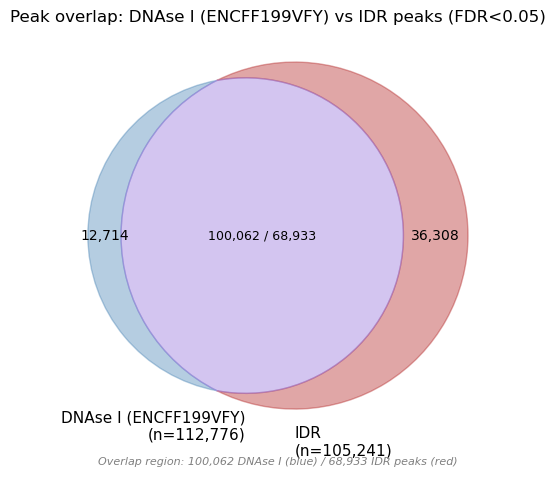

In [ ]:
from matplotlib_venn import venn2


# ------------------------------------------------------------------ #
# compute overlap counts
# ------------------------------------------------------------------ #
dnase_key = [k for k in pr_dict.keys() if "ENCFF199VFY" in k or "dnase" in k][0]
idr_key  = [k for k in pr_dict.keys() if "idr" in k.lower()][0]

dnase_pr = pr_dict[dnase_key]
idr_pr  = pr_dict[idr_key]

dnase_df = dnase_pr.df.copy()
idr_df  = idr_pr.df.copy()

dnase_overlapping = set()
idr_overlapping  = set()

for chrom in dnase_df["Chromosome"].unique():
    f = dnase_df[dnase_df["Chromosome"] == chrom]
    i = idr_df[idr_df["Chromosome"] == chrom]
    if i.empty:
        continue
    for _, frow in f.iterrows():
        hits = i[(i["Start"] < frow["End"]) & (i["End"] > frow["Start"])]
        if not hits.empty:
            dnase_overlapping.add((chrom, frow["Start"], frow["End"]))
            for _, irow in hits.iterrows():
                idr_overlapping.add((chrom, irow["Start"], irow["End"]))

dnase_only = len(dnase_df) - len(dnase_overlapping)
idr_only  = len(idr_df)  - len(idr_overlapping)
dnase_shared = len(dnase_overlapping)
idr_shared  = len(idr_overlapping)

print(f"DNAse I only              : {dnase_only:,}")
print(f"IDR only               : {idr_only:,}")
print(f"DNAse I peaks w/ IDR hit  : {dnase_shared:,}")
print(f"IDR peaks w/ DNAse I hit  : {idr_shared:,}")

# Sets for venn2: (only_A, only_B, shared)
venn = venn2(
    subsets=(dnase_only, idr_only, dnase_shared),
    set_labels=(f"DNAse I (ENCFF199VFY)\n(n={len(dnase_df):,})", 
                f"IDR\n(n={len(idr_df):,})")
)

# Style the circles
venn.get_patch_by_id('10').set_color('steelblue')
venn.get_patch_by_id('10').set_alpha(0.4)
venn.get_patch_by_id('01').set_color('firebrick')
venn.get_patch_by_id('01').set_alpha(0.4)
venn.get_patch_by_id('11').set_color('mediumpurple')
venn.get_patch_by_id('11').set_alpha(0.4)

# Override overlap label to show both counts (many-to-many)
venn.get_label_by_id('10').set_text(f'{dnase_only:,}')
venn.get_label_by_id('01').set_text(f'{idr_only:,}')
venn.get_label_by_id('11').set_text(f'{dnase_shared:,} / {idr_shared:,}')
venn.get_label_by_id('11').set_fontsize(9)

# Style set labels
for label in venn.set_labels:
    label.set_fontsize(11)

plt.title("Peak overlap: DNAse I (ENCFF199VFY) vs IDR peaks (FDR<0.05)", fontsize=12)
plt.figtext(0.5, 0.02,
            f"\nOverlap region: {dnase_shared:,} DNAse I (blue) / {idr_shared:,} IDR peaks (red)",
            ha='center', fontsize=8, style='italic', color='grey')
plt.tight_layout()
plt.savefig("venn_dnase_idr.pdf",  bbox_inches='tight')
plt.show()

In [22]:
# Treating DNAse as ground truth, IDR as predictor
# TP = IDR peaks that overlap DNAse  → idr_overlapping
# FP = IDR peaks with no DNAse overlap
# FN = DNAse peaks not recovered by IDR

precision = len(idr_overlapping)   / len(idr_df)   if len(idr_df)   > 0 else 0
recall    = len(dnase_overlapping) / len(dnase_df)  if len(dnase_df) > 0 else 0
f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("=" * 40)
print(f"\nTreating DNAse as ground truth:")
print(f"  Precision (IDR peaks confirmed by DNAse)  : {precision:.3f} ({precision*100:.1f}%)")
print(f"  Recall    (DNAse peaks recovered by IDR)  : {recall:.3f} ({recall*100:.1f}%)")
print(f"  F1 score                                  : {f1:.3f}")
print("=" * 40)


Treating DNAse as ground truth:
  Precision (IDR peaks confirmed by DNAse)  : 0.655 (65.5%)
  Recall    (DNAse peaks recovered by IDR)  : 0.887 (88.7%)
  F1 score                                  : 0.754


In [18]:
pip list

Package                 Version
----------------------- -----------
asttokens               3.0.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
fonttools               4.60.1
importlib_metadata      8.7.0
ipykernel               7.1.0
ipython                 9.7.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.6.3
jupyter_core            5.9.1
kiwisolver              1.4.9
legendkit               0.3.4
marsilea                0.5.6
matplotlib              3.10.8
matplotlib-inline       0.2.1
matplotlib-venn         1.1.2
munkres                 1.1.4
natsort                 8.4.0
ncls                    0.0.70
nest_asyncio            1.6.0
numpy                   2.3.5
packaging               25.0
pandas                  2.3.3
parso                   0.8.5
patsy                   1.0.2
pexpect                 4.9